# **Day 2.3: Optimization**
**Module Theme:** Turning Gradients into Better Weights  
**Estimated Time:** 0.5 hour  
**Prerequisites:** Note 2.2 - Learning Mechanisms

## **📚 Table of Contents**
- [2.3.1 Optimizers: SGD, Adam, RMSprop (When to Use Each)](#231-optimizers-sgd-adam-rmsprop-when-to-use-each)
- [2.3.2 Parameter Initialization & Learning Rates](#232-parameter-initialization--learning-rates)
- [2.3.3 The Complete Training Cycle: Putting It All Together](#233-the-complete-training-cycle-putting-it-all-together)
- [Summary & Transition to Note 2.4](#summary--transition-to-note-24)

In [9]:
%%html
<style>
.jp-RenderedMarkdown table {
    font-size: 16px !important;
    line-height: 1.6 !important;
    border-collapse: collapse !important;
    width: 100% !important;
    margin: 20px 0 !important;
    font-family: 'Segoe UI', Tahoma, Geneva, Verdana, sans-serif !important;
}

.jp-RenderedMarkdown table th {
    background-color: #2c3e50 !important;
    color: white !important;
    padding: 15px 20px !important;
    text-align: left !important;
    font-weight: 600 !important;
    font-size: 16px !important;
    border: none !important;
}

.jp-RenderedMarkdown table td {
    padding: 15px 20px !important;
    border: none !important;
    border-bottom: 1px solid #e0e0e0 !important;
    vertical-align: top !important;
}

.jp-RenderedMarkdown table tr:nth-child(even) {
    background-color: #f8f9fa !important;
}

.jp-RenderedMarkdown table tr:nth-child(odd) {
    background-color: white !important;
}

.jp-RenderedMarkdown table tr:hover {
    background-color: #e3f2fd !important;
}

/* Style the first column differently */
.jp-RenderedMarkdown table td:first-child {
    font-weight: 600 !important;
    color: #2c3e50 !important;
    background-color: #f5f5f5 !important;
}

.jp-RenderedMarkdown table tr:nth-child(even) td:first-child {
    background-color: #eeeeee !important;
}
</style>

## 2.3.1 ⚡ Neural Network Optimization Process

### Definition

**Optimization** is the process of updating neural network weights using gradients computed by backpropagation. It's the final step that actually improves the model by moving weights in directions that reduce the loss function.

**In simple terms**: Backpropagation tells us "which way to go," optimization decides "how far to step."

### Idea & Intuition 🎯

#### The Mountain Climbing Analogy
Imagine you're blindfolded on a mountain and want to reach the bottom:
- **Backpropagation** = feeling the slope with your feet (finding the gradient)
- **Optimization** = actually taking steps downhill (updating weights)
- **Learning rate** = how big steps you take

<div align="center">
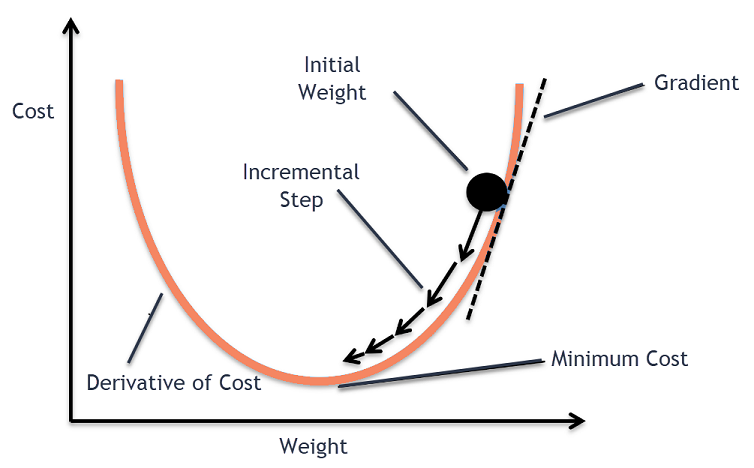
</div>

#### Key Insight
**Gradients point uphill** (toward higher loss), so we move in the **opposite direction** to go downhill (toward lower loss).

```
Gradient = +2.0  →  Move left  (decrease weight)
Gradient = -1.5  →  Move right (increase weight)
Gradient = 0.0   →  Stay put   (optimal point)
```

### Connection to Backward Propagation 🔄

#### The Complete Learning Cycle
<div align="center">
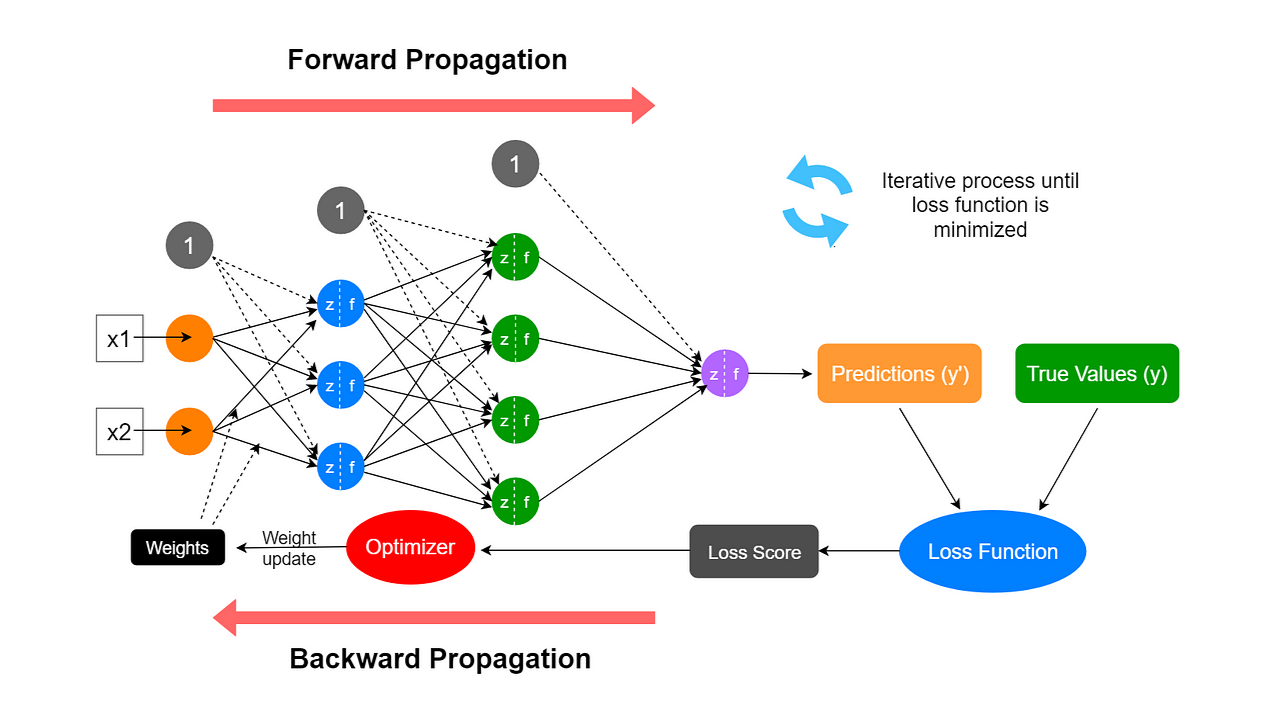
</div>

#### The Handoff
1. **Backpropagation outputs**: Gradients for every weight ($\frac{\partial L}{\partial w}$)
2. **Optimization inputs**: Those same gradients  
3. **Optimization outputs**: Updated weights ($w_{new}$)

#### Why They're Inseparable
- **Backpropagation without optimization** = knowing the problem but not fixing it
- **Optimization without backpropagation** = blind guessing with no direction

### The Optimization Process 📋

#### Basic Update Rule (Gradient Descent)

$$w_{new} = w_{old} - \alpha \frac{\partial L}{\partial w}$$

Where:
- $w_{old}$ = current weight value
- $\alpha$ = learning rate (step size)
- $\frac{\partial L}{\partial w}$ = gradient from backpropagation
- $w_{new}$ = updated weight value

#### Step-by-Step Process

1. **Receive gradients** from backpropagation for all weights
2. **Apply update rule** to each weight individually  
3. **Store new weights** in the model
4. **Repeat** for next training batch

#### The Learning Rate Role

**Learning Rate** controls how large steps the optimizer takes in the gradient direction.

```python
# Learning rate controls step size
α = 0.001  # Small steps (safe but slow)
α = 0.1    # Medium steps (balanced)  
α = 1.0    # Large steps (fast but risky)
```

**Effect on weight updates**:
- **Too small**: Learning is very slow
- **Too large**: May overshoot and miss the minimum
- **Just right**: Efficient convergence to minimum

#### Learning Rate
<div align="center">
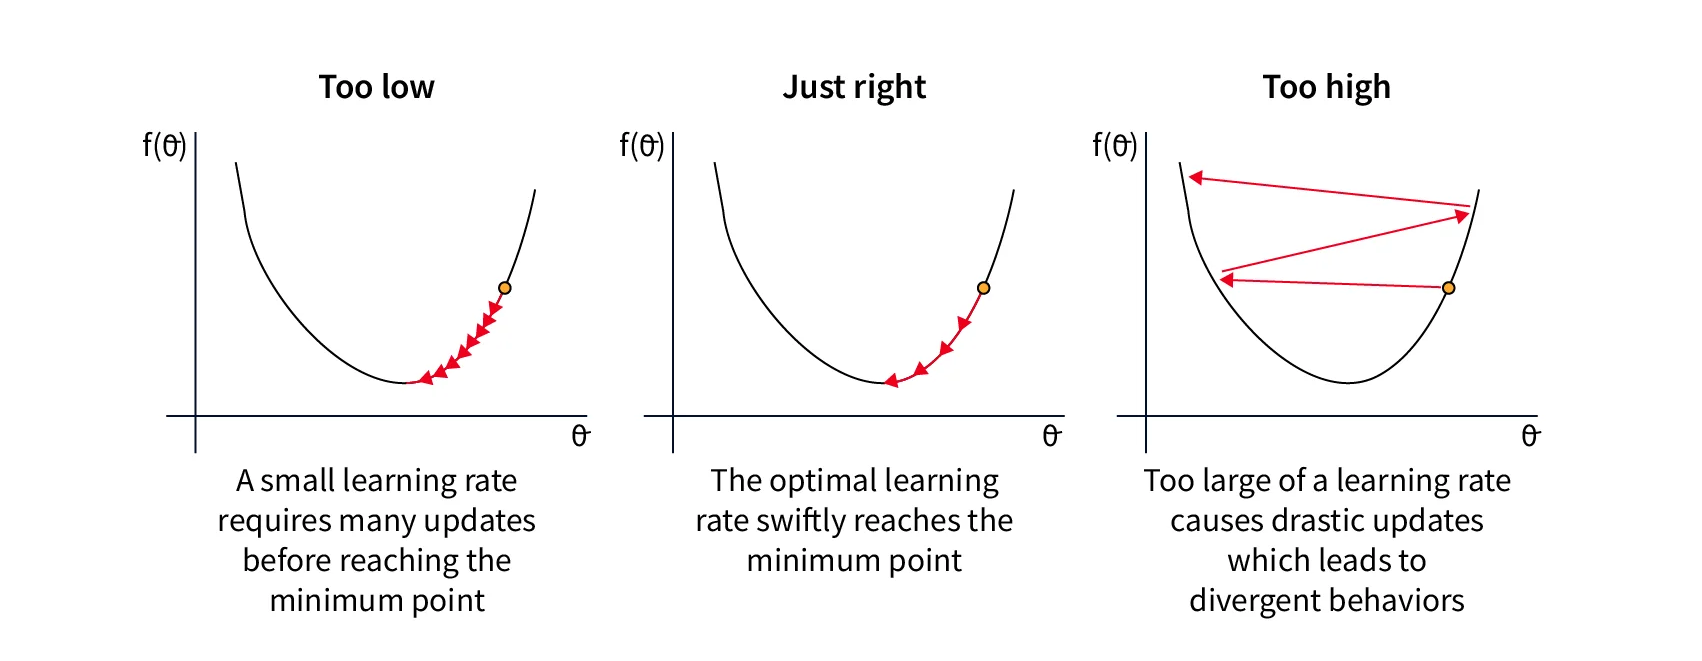
</div>

### Visual Summary 📊

```
🔄 FROM GRADIENTS TO BETTER WEIGHTS

Backpropagation Output:           Optimization Process:
┌─────────────────────┐          ┌─────────────────────┐
│  ∂L/∂W₁ = -0.5     │   ────▶  │ W₁ += 0.1 × 0.5    │
│  ∂L/∂W₂ = +1.2     │          │ W₂ -= 0.1 × 1.2    │
│  ∂L/∂W₃ = -0.8     │          │ W₃ += 0.1 × 0.8    │
│  ...                │          │ ...                 │
│  (All gradients)    │          │ (All weights updated)│
└─────────────────────┘          └─────────────────────┘

Result: Weights move toward lower loss!
```

#### 🎯 Key Takeaways

1. **Optimization is the action phase** - it actually changes the weights
2. **Always moves opposite to gradients** - downhill toward lower loss
3. **Learning rate is crucial** - controls how aggressive the updates are
4. **Different optimizers** handle gradients in sophisticated ways
5. **Happens after every forward/backward pass** - continuous improvement

**Remember**: Backpropagation computes the gradients, optimization applies them. Together, they make the network learn!

## **2.3.2 Optimizers: SGD, Adam, RMSprop (When to Use Each)**
*Estimated Time: 10 minutes*

### **⚡ The Weight Update Engine**

The **Optimizer** is the algorithm that takes gradients from backpropagation and actually **updates** the weights and biases. It dictates *how* the model navigates the "loss landscape" to find the minimum loss.

Think of optimization like **hiking down a mountain in the fog**:
- **🏔️ Mountain:** The loss landscape (high loss = peak, low loss = valley)
- **🧭 Compass:** Gradients show the steepest downhill direction
- **👟 Step Size:** Learning rate controls how big steps you take
- **🎯 Goal:** Reach the lowest valley (minimum loss)

Different optimizers use different strategies to navigate the loss landscape and find the minimum loss.

**The Big Picture**: All optimizers take gradients and update weights, but they differ in **how smart** they are about it.

#### 1. **SGD (Stochastic Gradient Descent) 🎯**

**Key Idea**
Follow the gradient direction with a **fixed step size**. It's the simplest and most straightforward optimizer - pure gradient descent with no fancy tricks.

**Formula**
$$w_{t+1} = w_t - \alpha \nabla L(w_t)$$

Where:
- $w_t$ = current weights
- $\alpha$ = learning rate (constant)
- $\nabla L(w_t)$ = gradients from backpropagation

**When to Use**
- **Educational purposes** - understanding optimization fundamentals
- **Simple problems** with well-behaved loss landscapes
- **When you need interpretability** and want to understand exactly what's happening
- **Memory-constrained environments**

**Advantages ✅**
- **Simple and interpretable** - easy to understand what it's doing
- **Memory efficient** - only stores current weights
- **Stable** - predictable behavior
- **Works well with proper tuning** - can achieve good results

**Disadvantages ❌**
- **Can be slow** - takes small, uniform steps
- **Sensitive to learning rate** - requires careful tuning
- **Gets stuck easily** - in plateaus or local minima
- **Same step size for all weights** - inefficient for different parameter scales

**Keras Implementation**
```python
from tensorflow.keras.optimizers import SGD

# Basic SGD
model.compile(optimizer='sgd', loss='mse')

# SGD with custom learning rate
model.compile(optimizer=SGD(learning_rate=0.01), loss='mse')

# SGD with momentum (recommended)
model.compile(optimizer=SGD(learning_rate=0.01, momentum=0.9), loss='mse')
```

**Visual Behavior**
<div align="center">
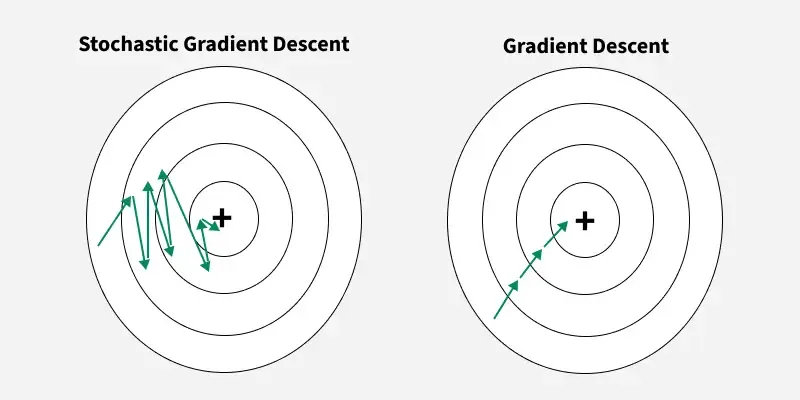
</div>
Characteristics: Steady, uniform progress

#### **2. RMSprop (Root Mean Square Propagation) 📊**

**Key Idea**
**Adapt step size for each weight** based on recent gradient history. Weights that have been changing a lot get smaller updates, weights that have been stable get larger updates.

**Formula**
$$v_t = \beta v_{t-1} + (1-\beta)(\nabla L(w_t))^2$$
$$w_{t+1} = w_t - \frac{\alpha}{\sqrt{v_t + \epsilon}} \nabla L(w_t)$$

Where:
- $v_t$ = running average of squared gradients
- $\beta$ = decay factor (typically 0.9)
- $\epsilon$ = small constant to prevent division by zero

**When to Use**
- **RNN/LSTM training** - excellent for recurrent networks
- **When Adam fails** - sometimes more stable than Adam
- **Non-stationary objectives** - when the optimal solution changes over time
- **When you need adaptive learning rates** but want simpler than Adam

**Advantages ✅**
- **Adaptive learning rates** - automatically adjusts for each weight
- **Good for RNNs** - handles vanishing/exploding gradients well
- **Handles sparse gradients** - works well with irregular updates
- **More stable than early Adam versions**

**Disadvantages ❌**
- **Can decay learning rate too aggressively** - may stop learning too early
- **No momentum** - doesn't build up speed in consistent directions
- **Sensitive to initial learning rate** - still requires some tuning
- **Can get stuck** - in later stages of training

**Keras Implementation**
```python
from tensorflow.keras.optimizers import RMSprop

# Basic RMSprop
model.compile(optimizer='rmsprop', loss='mse')

# RMSprop with custom parameters
model.compile(
    optimizer=RMSprop(learning_rate=0.001, rho=0.9),
    loss='mse'
)

# Recommended for RNN/LSTM
model = Sequential([
    LSTM(64, return_sequences=True),
    LSTM(32),
    Dense(1)
])
model.compile(optimizer='rmsprop', loss='mse')
```

**Visual Behavior**
```
RMSprop Adaptive Steps:
Start ●───→●──→●─→●→● Minimum
     Big  Med Sm Tiny
     step step step step

Characteristics: Automatically slows down as it approaches minimum
```

#### **3. Adam (Adaptive Moment Estimation) 🚀**

**Key Idea**
**Best of both worlds** - combines momentum (builds up speed) with adaptive learning rates (smart step sizes). It's like having a smart car with both acceleration and adaptive cruise control.

**Formula**
$$m_t = \beta_1 m_{t-1} + (1-\beta_1) \nabla L(w_t)$$ (momentum)
$$v_t = \beta_2 v_{t-1} + (1-\beta_2) (\nabla L(w_t))^2$$ (adaptive rates)
$$w_{t+1} = w_t - \frac{\alpha}{\sqrt{v_t} + \epsilon} m_t$$ (update)

Where:
- $m_t$ = momentum (exponential average of gradients)
- $v_t$ = adaptive rates (exponential average of squared gradients)
- $\beta_1$ = momentum decay (typically 0.9)
- $\beta_2$ = adaptive rate decay (typically 0.999)

**When to Use**
- **Default choice for 90% of problems** - start here unless you have a specific reason not to
- **Deep neural networks** - CNNs, transformers, etc.
- **When you want fast convergence** with minimal tuning
- **Large datasets** - scales well with big data
- **Most modern architectures** - proven track record

**Advantages ✅**
- **Fast convergence** - typically reaches good solutions quickly
- **Robust** - works well across many different problems
- **Little tuning needed** - default parameters often work well
- **Combines best features** - momentum + adaptive rates
- **Handles sparse gradients** - works with irregular updates

**Disadvantages ❌**
- **Can overfit** - may find solutions that don't generalize well
- **Slightly more memory usage** - stores both momentum and adaptive rate history
- **Sometimes too aggressive** - may overshoot in fine-tuning phase
- **Not always best for final convergence** - sometimes SGD is better for final polish

**Keras Implementation**
```python
from tensorflow.keras.optimizers import Adam

# Basic Adam (recommended starting point)
model.compile(optimizer='adam', loss='mse')

# Adam with custom learning rate
model.compile(optimizer=Adam(learning_rate=0.001), loss='mse')

# Adam with custom parameters
model.compile(
    optimizer=Adam(
        learning_rate=0.001,
        beta_1=0.9,      # momentum decay
        beta_2=0.999,    # adaptive rate decay
        epsilon=1e-7
    ),
    loss='mse'
)

# Typical deep learning setup
model = Sequential([
    Dense(128, activation='relu'),
    Dropout(0.2),
    Dense(64, activation='relu'),
    Dense(10, activation='softmax')
])
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy')
```

**Visual Behavior**
```
Adam Smart Navigation:
Start ●━━━━━━━━━━━━━━━━━━━━━━━━→● Minimum
     Fast momentum builds up,
     then slows down smartly

Characteristics: Accelerates when consistent, slows when approaching target
```

**📊 Optimizer Comparison Diagram**

```
OPTIMIZATION STRATEGIES COMPARISON:

SGD:        ●─→●─→●─→●─→●─→●─→● 
            Steady, uniform steps

RMSprop:    ●──→●─→●→● 
            Adaptive step sizes

Adam:       ●━━━━━━━━→● 
            Smart acceleration + adaptation

Loss Landscape Visualization:
            ╭─╮
           ╱   ╲
          ╱     ╲
         ╱   ●   ╲    ← All optimizers trying to reach bottom
        ╱  (min)  ╲
       ╱___________╲

SGD:     Takes careful, measured steps
RMSprop: Adapts step size based on terrain  
Adam:    Builds momentum AND adapts step size
```

**🎯 Quick Decision Guide**

```python
# Which optimizer should you choose?

if problem == "learning_fundamentals":
    optimizer = 'sgd'
    
elif problem == "RNN" or problem == "LSTM":
    optimizer = 'rmsprop'
    
elif problem == "anything_else":
    optimizer = 'adam'  # Start here 90% of the time
    
# If Adam doesn't work well, try:
# 1. Lower learning rate: Adam(learning_rate=0.0001)
# 2. Switch to RMSprop
# 3. Try SGD with momentum for final fine-tuning
```

**📋 Complete Comparison Table**

| Feature | SGD | RMSprop | Adam |
|---------|-----|---------|------|
| **Learning Rate** | Fixed | Adaptive | Adaptive |
| **Momentum** | Optional | No | Yes |
| **Memory Usage** | Low | Medium | Medium |
| **Convergence Speed** | Slow | Medium | Fast |
| **Hyperparameter Sensitivity** | High | Medium | Low |
| **Best For** | Simple problems | RNNs | Most problems |
| **Default Learning Rate** | 0.01 | 0.001 | 0.001 |

**🔧 Practical Usage Examples**

```python
# Common patterns in practice

# 1. Start with Adam for new projects
model.compile(optimizer='adam', loss='categorical_crossentropy')

# 2. For RNNs, prefer RMSprop
model.compile(optimizer='rmsprop', loss='mse')

# 3. For final fine-tuning, sometimes switch to SGD
# Train with Adam first, then switch:
model.compile(optimizer=SGD(learning_rate=0.0001, momentum=0.9), loss='mse')

# 4. Learning rate scheduling with any optimizer
from tensorflow.keras.callbacks import ReduceLROnPlateau
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=5)
model.fit(X, y, callbacks=[reduce_lr])
```

**🎯 Key Takeaways**

1. **Adam is the default choice** - works well for most problems with minimal tuning
2. **RMSprop for RNNs** - especially good for sequence models
3. **SGD for understanding** - best for learning optimization fundamentals
4. **All use the same gradients** - from backpropagation, just apply them differently
5. **Can switch optimizers** - during training for different phases
6. **Learning rate still matters** - even with adaptive optimizers

**Remember**: The optimizer is just the strategy for using gradients to update weights. The gradients come from backpropagation, regardless of which optimizer you choose!

### **📊 The Essential Optimizer Reference**

| Optimizer | Keras Name | Key Idea | When to Use | Pros | Cons |
|-----------|------------|----------|-------------|------|------|
| **SGD** | `'sgd'` | Follow the gradient direction with fixed step size | Educational purposes, simple problems | Simple, interpretable, memory efficient | Can be slow, sensitive to learning rate |
| **RMSprop** | `'rmsprop'` | Adapt step size for each weight based on recent gradient history | RNN/LSTM training, when Adam fails | Good for non-stationary objectives | Can decay learning rate too aggressively |
| **Adam** | `'adam'` | **Best of both worlds:** Combines momentum + adaptive learning rates | **Default choice for 90% of problems** | Fast convergence, robust, little tuning needed | Can overfit, slightly more memory usage |

### **🎯 The Learning Rate: Your Most Important Hyperparameter**

##### 🐌 TOO SMALL (e.g., 0.0001):
- ✅ Stable training
- ❌ Very slow learning
- ❌ May get stuck in local minima
- 🎯 **Like taking tiny baby steps down a mountain**

##### 🚀 TOO LARGE (e.g., 0.1):
- ❌ Unstable training
- ❌ May overshoot the minimum
- ❌ Loss might explode or oscillate
- 🎯 **Like taking giant leaps - might jump over the valley!**

##### ✨ JUST RIGHT (e.g., 0.001 for Adam):
- ✅ Steady progress toward minimum
- ✅ Fast enough learning
- ✅ Stable convergence
- 🎯 **Like confident hiking steps - quick but controlled**

##### 🧭 Default Learning Rates (good starting points):
- **Adam:** 0.001 (most versatile)
- **SGD:** 0.01 (needs higher rate)
- **RMSprop:** 0.001

##### 🚨 Warning Signs:
- **📈 Loss increasing** → Learning rate probably too high
- **🐌 Loss barely decreasing** → Learning rate probably too low
- **📊 Loss oscillating wildly** → Definitely too high

##### Quick Rules:
1. **Start with defaults** (Adam: 0.001, SGD: 0.01)
2. **If training is unstable** → Lower the learning rate
3. **If training is too slow** → Increase the learning rate
4. **When in doubt** → Try 0.001 with Adam optimizer

### **⚖️ Optimizer Selection Decision Tree**

##### 🎯 START HERE: Use Adam with lr=0.001
- Works for 90% of deep learning problems
- Fast convergence  
- Requires minimal tuning

##### 🔄 IF Adam doesn't work well:
- **Try RMSprop** (lr=0.001)
- **Try SGD with momentum** (lr=0.01)
- **Experiment with learning rate**

##### 📚 Educational/Research:
- **Start with SGD** to understand optimization
- **Compare different optimizers** on same problem

##### 🚨 Troubleshooting:

**Problem: Training loss not decreasing**
- Solution 1: Lower learning rate (try 0.0001)
- Solution 2: Try different optimizer
- Solution 3: Check data preprocessing

**Problem: Training too slow**
- Solution 1: Increase learning rate (try 0.01)  
- Solution 2: Switch to Adam if using SGD
- Solution 3: Increase batch size

##### Quick Decision Tree
1. **First time?** → Start with Adam (lr=0.001)
2. **Adam not working?** → Try RMSprop or SGD
3. **Learning?** → Use SGD to understand concepts
4. **Problems?** → Check troubleshooting guide above

### Keras Implementation 💻

#### Basic Optimizer Setup
```python
import tensorflow as tf
from tensorflow.keras.optimizers import SGD, Adam, RMSprop

# Different optimizers use gradients differently
optimizers = {
    'sgd': SGD(learning_rate=0.01),
    'adam': Adam(learning_rate=0.001),  # Most popular
    'rmsprop': RMSprop(learning_rate=0.001)
}

# Compile model with chosen optimizer
model.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae']
)
```

#### What Happens During Training
```python
# Training step (happens automatically in model.fit())
for batch in dataset:
    X_batch, y_batch = batch
    
    # 1. Forward + Backward (compute gradients)
    with tf.GradientTape() as tape:
        predictions = model(X_batch, training=True)
        loss_value = loss_function(y_batch, predictions)
    gradients = tape.gradient(loss_value, model.trainable_variables)
    
    # 2. OPTIMIZATION: Apply gradients to update weights
    optimizer.apply_gradients(zip(gradients, model.trainable_variables))
```

### **🧠 Knowledge Check Questions - Section 2.3.1**

**Question 1:** You're training a model and the loss keeps oscillating wildly up and down. What's the most likely problem and solution?

<details>
<summary>Click for answer</summary>

**Problem:** Learning rate is too high - the optimizer is taking steps that are too large and overshooting the minimum.  
**Solution:** Reduce the learning rate (try 10x smaller, e.g., from 0.01 to 0.001).
</details>

**Question 2:** When would you choose SGD over Adam?

<details>
<summary>Click for answer</summary>

**Educational purposes** (to understand optimization fundamentals), **when you have unlimited time to tune hyperparameters**, or **in specific research scenarios** where you need the simplicity and interpretability of basic gradient descent.
</details>

**Question 3:** Why is Adam called "Adaptive Moment Estimation"?

<details>
<summary>Click for answer</summary>

**Adaptive:** It adapts the learning rate for each parameter individually  
**Moment:** It uses both first moment (mean) and second moment (variance) of gradients  
**Estimation:** It estimates these moments from the gradient history to make smarter updates
</details>

## **2.3.2 Parameter Initialization & Learning Rates**
*Estimated Time: 10 minutes*

### **🎲 Parameter Initialization: The Starting Point Matters**

How we **initialize** the weights before training can make or break the learning process. Poor initialization can lead to vanishing gradients, exploding gradients, or slow learning.

In [3]:
# Code cell demonstrating parameter initialization
def parameter_initialization_demo():
    print("🎲 Parameter Initialization: Why It Matters")
    print("=" * 43)
    
    import numpy as np
    
    print("❌ BAD INITIALIZATION: All zeros")
    print("   Problem: All neurons learn identical features")
    print("   Result: Network can't learn complex patterns")
    
    print("\n❌ BAD INITIALIZATION: Too large (e.g., random values from -5 to 5)")
    print("   Problem: Activations explode, gradients explode")
    print("   Result: Training becomes unstable")
    
    print("\n❌ BAD INITIALIZATION: Too small (e.g., random values from -0.001 to 0.001)")
    print("   Problem: Activations vanish, gradients vanish")
    print("   Result: Very slow or no learning")
    
    print("\n✅ GOOD INITIALIZATION: Keras defaults (Xavier/He initialization)")
    print("   Strategy: Scale weights based on layer size")
    print("   Result: Stable gradients, faster convergence")
    
    # Demonstrate with a simple example
    print("\n📊 Example: Layer with 100 inputs, 50 neurons")
    layer_inputs = 100
    layer_neurons = 50
    
    # Xavier/Glorot initialization (Keras default for most activations)
    xavier_std = np.sqrt(2.0 / (layer_inputs + layer_neurons))
    print(f"   Xavier std: {xavier_std:.4f}")
    
    # He initialization (better for ReLU)
    he_std = np.sqrt(2.0 / layer_inputs)
    print(f"   He std: {he_std:.4f}")
    
    print("\n💡 Key Insight:")
    print("   Keras handles this automatically!")
    print("   You rarely need to worry about initialization")
    print("   But understanding it helps debug training problems")

parameter_initialization_demo()

🎲 Parameter Initialization: Why It Matters
❌ BAD INITIALIZATION: All zeros
   Problem: All neurons learn identical features
   Result: Network can't learn complex patterns

❌ BAD INITIALIZATION: Too large (e.g., random values from -5 to 5)
   Problem: Activations explode, gradients explode
   Result: Training becomes unstable

❌ BAD INITIALIZATION: Too small (e.g., random values from -0.001 to 0.001)
   Problem: Activations vanish, gradients vanish
   Result: Very slow or no learning

✅ GOOD INITIALIZATION: Keras defaults (Xavier/He initialization)
   Strategy: Scale weights based on layer size
   Result: Stable gradients, faster convergence

📊 Example: Layer with 100 inputs, 50 neurons
   Xavier std: 0.1155
   He std: 0.1414

💡 Key Insight:
   Keras handles this automatically!
   You rarely need to worry about initialization
   But understanding it helps debug training problems


### **🎯 Learning Rate Schedules: Dynamic Adaptation**

Sometimes we want to **change the learning rate during training**:

In [4]:
# Code cell showing learning rate scheduling concepts
def learning_rate_scheduling():
    print("📈 Learning Rate Scheduling")
    print("=" * 28)
    
    print("🎯 The Idea: Start fast, then slow down")
    print("   • Early training: Large steps to make quick progress")
    print("   • Later training: Small steps to fine-tune")
    
    print("\n📊 Common Strategies:")
    
    print("\n1. 🔽 Step Decay:")
    print("   • Reduce LR by factor (e.g., 0.5) every N epochs")
    print("   • Example: 0.001 → 0.0005 → 0.00025")
    
    print("\n2. 📉 Exponential Decay:")
    print("   • Gradually decrease LR each epoch")
    print("   • Smooth reduction over time")
    
    print("\n3. 🎯 ReduceLROnPlateau:")
    print("   • Reduce LR when loss stops improving")
    print("   • Automatic adaptation based on training progress")
    
    print("\n✅ Keras Implementation Preview (Day 4):")
    print("   from tensorflow.keras.callbacks import ReduceLROnPlateau")
    print("   reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5)")
    
    print("\n💡 When to Use:")
    print("   🎯 Most beginners: Stick with fixed learning rate")
    print("   🚀 Advanced users: Experiment with scheduling")
    print("   📊 Long training: Almost always beneficial")

learning_rate_scheduling()

📈 Learning Rate Scheduling
🎯 The Idea: Start fast, then slow down
   • Early training: Large steps to make quick progress
   • Later training: Small steps to fine-tune

📊 Common Strategies:

1. 🔽 Step Decay:
   • Reduce LR by factor (e.g., 0.5) every N epochs
   • Example: 0.001 → 0.0005 → 0.00025

2. 📉 Exponential Decay:
   • Gradually decrease LR each epoch
   • Smooth reduction over time

3. 🎯 ReduceLROnPlateau:
   • Reduce LR when loss stops improving
   • Automatic adaptation based on training progress

✅ Keras Implementation Preview (Day 4):
   from tensorflow.keras.callbacks import ReduceLROnPlateau
   reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5)

💡 When to Use:
   🎯 Most beginners: Stick with fixed learning rate
   🚀 Advanced users: Experiment with scheduling
   📊 Long training: Almost always beneficial


### **🚨 Common Optimization Issues & Solutions**

In [5]:
# Code cell with troubleshooting guide
def optimization_troubleshooting():
    print("🚨 Optimization Troubleshooting Guide")
    print("=" * 35)
    
    issues = [
        {
            "problem": "Loss not decreasing at all",
            "causes": ["Learning rate too low", "Wrong loss function", "Data not preprocessed"],
            "solutions": ["Increase LR 10x", "Check problem-loss match", "Verify data scaling"]
        },
        {
            "problem": "Loss exploding (becoming very large)",
            "causes": ["Learning rate too high", "Gradient clipping needed"],
            "solutions": ["Decrease LR 10x", "Add gradient clipping", "Check for NaN values"]
        },
        {
            "problem": "Training very slow",
            "causes": ["Learning rate too low", "Optimizer choice", "Batch size too small"],
            "solutions": ["Increase LR", "Switch to Adam", "Increase batch size"]
        },
        {
            "problem": "Loss oscillating/unstable",
            "causes": ["Learning rate too high", "Batch size too small"],
            "solutions": ["Decrease LR", "Increase batch size", "Try different optimizer"]
        }
    ]
    
    for i, issue in enumerate(issues, 1):
        print(f"\n{i}. 🔴 Problem: {issue['problem']}")
        print("   🔍 Likely causes:")
        for cause in issue['causes']:
            print(f"      • {cause}")
        print("   ✅ Solutions to try:")
        for solution in issue['solutions']:
            print(f"      • {solution}")

optimization_troubleshooting()

🚨 Optimization Troubleshooting Guide

1. 🔴 Problem: Loss not decreasing at all
   🔍 Likely causes:
      • Learning rate too low
      • Wrong loss function
      • Data not preprocessed
   ✅ Solutions to try:
      • Increase LR 10x
      • Check problem-loss match
      • Verify data scaling

2. 🔴 Problem: Loss exploding (becoming very large)
   🔍 Likely causes:
      • Learning rate too high
      • Gradient clipping needed
   ✅ Solutions to try:
      • Decrease LR 10x
      • Add gradient clipping
      • Check for NaN values

3. 🔴 Problem: Training very slow
   🔍 Likely causes:
      • Learning rate too low
      • Optimizer choice
      • Batch size too small
   ✅ Solutions to try:
      • Increase LR
      • Switch to Adam
      • Increase batch size

4. 🔴 Problem: Loss oscillating/unstable
   🔍 Likely causes:
      • Learning rate too high
      • Batch size too small
   ✅ Solutions to try:
      • Decrease LR
      • Increase batch size
      • Try different optimizer


### **🧠 Knowledge Check Questions - Section 2.3.2**

**Question 1:** Why can't we initialize all weights to zero in a neural network?

<details>
<summary>Click for answer</summary>

If all weights start at zero, all neurons in each layer will compute identical outputs and receive identical gradients during backpropagation. This means they'll all update in exactly the same way, making them essentially the same neuron. The network loses its ability to learn diverse features.
</details>

**Question 2:** What's the main advantage of learning rate scheduling over using a fixed learning rate?

<details>
<summary>Click for answer</summary>

**Early training:** Large learning rates enable fast progress toward the minimum  
**Late training:** Small learning rates allow fine-tuning and stable convergence  
This combination often achieves both faster training and better final performance.
</details>

**Question 3:** Your model's loss starts at 2.5, drops to 0.8, then suddenly jumps to 15.7 and stays high. What happened and how do you fix it?

<details>
<summary>Click for answer</summary>

**What happened:** The optimizer took too large a step and "jumped out" of the good region of the loss landscape (learning rate too high).  
**How to fix:** Restart training with a lower learning rate (try 10x smaller) or implement gradient clipping to prevent large updates.
</details>

## **2.3.3 The Complete Training Cycle: Putting It All Together**
*Estimated Time: 10 minutes*

### **🔄 Part 1: The Learning Loop Analogy**

Let's use **archery training** to understand how all our concepts work together:

In [6]:
# Code cell with archery analogy
def archery_training_analogy():
    print("🏹 The Complete Learning Cycle: Archery Training")
    print("=" * 48)
    
    print("🎯 An archer is learning to hit a bullseye...")
    print()
    
    print("1. 🏹 FORWARD PASS (Taking the Shot):")
    print("   • Archer draws bow and releases arrow")
    print("   • Arrow flies through the air (data flows through network)")
    print("   • Arrow hits target at specific location (model makes prediction)")
    
    print("\n2. 📊 LOSS CALCULATION (Measuring Performance):")
    print("   • Measure distance from bullseye (compare prediction to true label)")
    print("   • Far from center = high error/loss")
    print("   • Close to center = low error/loss")
    
    print("\n3. 🔄 BACKPROPAGATION (Analyzing What Went Wrong):")
    print("   • 'Why did I miss the target?'")
    print("   • Analyze: stance, grip, aim, release timing")
    print("   • Assign blame: 'My grip was 30% responsible, aim was 70% responsible'")
    print("   • Each factor gets a specific 'improvement score'")
    
    print("\n4. ⚡ OPTIMIZATION (Making Improvements):")
    print("   • Adjust technique based on analysis")
    print("   • Grip: small adjustment (low blame)")
    print("   • Aim: bigger adjustment (high blame)")
    print("   • Learning rate = how big adjustments to make")
    
    print("\n5. 🔁 REPEAT CYCLE:")
    print("   • Take another shot with improved technique")
    print("   • Measure new performance")
    print("   • Continue until consistently hitting bullseye!")
    
    print("\n💡 Key Insight:")
    print("   Every shot (training example) makes the archer slightly better")
    print("   The cycle continues until expert-level accuracy is achieved")

archery_training_analogy()

🏹 The Complete Learning Cycle: Archery Training
🎯 An archer is learning to hit a bullseye...

1. 🏹 FORWARD PASS (Taking the Shot):
   • Archer draws bow and releases arrow
   • Arrow flies through the air (data flows through network)
   • Arrow hits target at specific location (model makes prediction)

2. 📊 LOSS CALCULATION (Measuring Performance):
   • Measure distance from bullseye (compare prediction to true label)
   • Far from center = high error/loss
   • Close to center = low error/loss

3. 🔄 BACKPROPAGATION (Analyzing What Went Wrong):
   • 'Why did I miss the target?'
   • Analyze: stance, grip, aim, release timing
   • Assign blame: 'My grip was 30% responsible, aim was 70% responsible'
   • Each factor gets a specific 'improvement score'

4. ⚡ OPTIMIZATION (Making Improvements):
   • Adjust technique based on analysis
   • Grip: small adjustment (low blame)
   • Aim: bigger adjustment (high blame)
   • Learning rate = how big adjustments to make

5. 🔁 REPEAT CYCLE:
   • Take

### **🔢 Part 2: Concrete Mathematical Walkthrough**

Let's trace **one training example** through our breast cancer classification network:

In [7]:
# Code cell with detailed mathematical walkthrough
def training_cycle_walkthrough():
    print("🔢 Mathematical Walkthrough: One Training Cycle")
    print("=" * 46)
    
    import numpy as np
    
    # Simplified network: 3 inputs → 2 hidden → 1 output
    print("🏗️ Network Architecture: 3 → 2 → 1 (simplified)")
    print("📊 Problem: Predict if tumor is malignant (1) or benign (0)")
    print()
    
    # Sample input
    print("📥 STEP 1: FORWARD PASS")
    print("Input features: [0.8, -0.3, 1.2] (scaled tumor measurements)")
    
    # Layer 1: Input to Hidden
    W1 = np.array([[0.5, -0.2], [0.3, 0.7], [-0.1, 0.4]])  # 3x2 weights
    b1 = np.array([0.1, -0.1])  # 2 biases
    
    input_data = np.array([0.8, -0.3, 1.2])
    
    # Hidden layer computation
    z1 = np.dot(input_data, W1) + b1
    a1 = np.maximum(0, z1)  # ReLU activation
    
    print(f"Hidden layer: {z1.round(3)} → ReLU → {a1.round(3)}")
    
    # Layer 2: Hidden to Output
    W2 = np.array([[0.6], [0.4]])  # 2x1 weights
    b2 = np.array([0.2])  # 1 bias
    
    z2 = np.dot(a1, W2) + b2
    prediction = 1 / (1 + np.exp(-z2[0]))  # Sigmoid
    
    print(f"Output: {z2[0]:.3f} → Sigmoid → {prediction:.3f}")
    
    # Step 2: Loss calculation
    print(f"\n📊 STEP 2: LOSS CALCULATION")
    true_label = 1  # Actually malignant
    loss = -(true_label * np.log(prediction) + (1-true_label) * np.log(1-prediction))
    print(f"True label: {true_label}")
    print(f"Prediction: {prediction:.3f}")
    print(f"Binary crossentropy loss: {loss:.3f}")
    
    # Step 3: Backpropagation (simplified)
    print(f"\n🔄 STEP 3: BACKPROPAGATION (Blame Assignment)")
    print("Output layer gradient: High (prediction far from truth)")
    print("Hidden layer gradients: Calculated based on connection strengths")
    print("Input layer gradients: Propagated back through the network")
    
    # Step 4: Optimization
    print(f"\n⚡ STEP 4: OPTIMIZATION (Weight Updates)")
    learning_rate = 0.001
    print(f"Learning rate: {learning_rate}")
    print("Each weight updated: new_weight = old_weight - learning_rate * gradient")
    print("Weights with high blame get bigger adjustments")
    
    print(f"\n🔁 STEP 5: READY FOR NEXT EXAMPLE")
    print("Network is now slightly better at predicting malignant tumors!")
    print("Repeat this cycle for thousands of examples...")

training_cycle_walkthrough()

🔢 Mathematical Walkthrough: One Training Cycle
🏗️ Network Architecture: 3 → 2 → 1 (simplified)
📊 Problem: Predict if tumor is malignant (1) or benign (0)

📥 STEP 1: FORWARD PASS
Input features: [0.8, -0.3, 1.2] (scaled tumor measurements)
Hidden layer: [0.29 0.01] → ReLU → [0.29 0.01]
Output: 0.378 → Sigmoid → 0.593

📊 STEP 2: LOSS CALCULATION
True label: 1
Prediction: 0.593
Binary crossentropy loss: 0.522

🔄 STEP 3: BACKPROPAGATION (Blame Assignment)
Output layer gradient: High (prediction far from truth)
Hidden layer gradients: Calculated based on connection strengths
Input layer gradients: Propagated back through the network

⚡ STEP 4: OPTIMIZATION (Weight Updates)
Learning rate: 0.001
Each weight updated: new_weight = old_weight - learning_rate * gradient
Weights with high blame get bigger adjustments

🔁 STEP 5: READY FOR NEXT EXAMPLE
Network is now slightly better at predicting malignant tumors!
Repeat this cycle for thousands of examples...


### **🔄 Part 3: The Training Cycle Flowchart**

In [8]:
# Code cell creating a visual training cycle summary
def training_cycle_flowchart():
    print("🔄 The Complete Training Cycle Flowchart")
    print("=" * 40)
    
    print("""
    📥 INPUT DATA
          ↓
    🔄 FORWARD PASS
    (Data flows through layers)
          ↓
    📊 PREDICTION
    (Network outputs guess)
          ↓
    📏 LOSS CALCULATION
    (Compare to true label)
          ↓
    🔄 BACKPROPAGATION
    (Calculate gradients)
          ↓
    ⚡ OPTIMIZATION
    (Update weights)
          ↓
    🔁 REPEAT WITH NEXT BATCH
    """)
    
    print("🎯 Key Insights:")
    print("   • This cycle happens for EVERY batch of training data")
    print("   • Each cycle makes the network slightly more accurate")
    print("   • After thousands of cycles, the network becomes expert!")
    
    print("\n⚙️ The Components Working Together:")
    print("   🏗️ Architecture (2.1): Defines how information flows")
    print("   📊 Loss Function (2.2): Measures prediction quality")
    print("   🔄 Backpropagation (2.2): Calculates blame/gradients")
    print("   ⚡ Optimizer (2.3): Updates weights to improve performance")
    
    print("\n🧠 The Magic:")
    print("   No human tells the network HOW to recognize patterns")
    print("   The network discovers patterns automatically through this cycle")
    print("   This is why deep learning is so powerful!")

training_cycle_flowchart()

🔄 The Complete Training Cycle Flowchart

    📥 INPUT DATA
          ↓
    🔄 FORWARD PASS
    (Data flows through layers)
          ↓
    📊 PREDICTION
    (Network outputs guess)
          ↓
    📏 LOSS CALCULATION
    (Compare to true label)
          ↓
    🔄 BACKPROPAGATION
    (Calculate gradients)
          ↓
    ⚡ OPTIMIZATION
    (Update weights)
          ↓
    🔁 REPEAT WITH NEXT BATCH
    
🎯 Key Insights:
   • This cycle happens for EVERY batch of training data
   • Each cycle makes the network slightly more accurate
   • After thousands of cycles, the network becomes expert!

⚙️ The Components Working Together:
   🏗️ Architecture (2.1): Defines how information flows
   📊 Loss Function (2.2): Measures prediction quality
   🔄 Backpropagation (2.2): Calculates blame/gradients
   ⚡ Optimizer (2.3): Updates weights to improve performance

🧠 The Magic:
   No human tells the network HOW to recognize patterns
   The network discovers patterns automatically through this cycle
   This is 

### **🧠 Knowledge Check Questions - Section 2.3.3**

**Question 1:** In the archery analogy, what does "adjusting your grip and aim" correspond to in neural network training?

<details>
<summary>Click for answer</summary>

**Weight and bias updates** during the optimization step. Just like the archer adjusts technique based on where the arrow landed, the optimizer adjusts network parameters based on the gradients calculated from the prediction error.
</details>

**Question 2:** Why does this training cycle need to be repeated thousands of times?

<details>
<summary>Click for answer</summary>

Each cycle only makes **tiny improvements** to the weights. Complex patterns require learning from many different examples, and each example teaches the network something slightly different. Thousands of iterations allow the network to discover and refine complex patterns that generalize well.
</details>

**Question 3:** What would happen if we skipped the backpropagation step and just randomly updated weights?

<details>
<summary>Click for answer</summary>

**The network wouldn't learn effectively.** Random updates have no relationship to the actual errors, so the network would essentially be guessing forever. Backpropagation provides the crucial **direction** information that tells each weight how to change to reduce the loss.
</details>

**Question 4:** In one complete training cycle, which step actually changes the network's weights?

<details>
<summary>Click for answer</summary>

**Only the optimization step (#4).** Forward pass, loss calculation, and backpropagation are all about **calculating** what needs to change and by how much. The optimizer is what actually **implements** the weight updates.
</details>

## **📝 Summary & Transition to Note 2.4**

### **🎯 What We've Mastered in Note 2.3:**

✅ **Optimizers:** The engines that turn gradients into better weights  
✅ **Learning Rates:** The most crucial hyperparameter for stable training  
✅ **Parameter Initialization:** Why starting points matter for learning success  
✅ **The Complete Cycle:** How all pieces work together in perfect harmony  

### **🔗 The Theory is Complete!**

We now have **all the theoretical foundations** for deep learning:

- **🏗️ Architecture (2.1):** How networks are structured
- **📊 Loss Functions (2.2):** How we measure success
- **🔄 Backpropagation (2.2):** How we assign responsibility  
- **⚡ Optimization (2.3):** How we improve performance
- **🔁 Training Cycle (2.3):** How it all works together

**🤔 The Only Question Remaining:**

*"We understand the theory... but can we actually BUILD one?"*

### **🚀 Coming Up in Note 2.4: Keras API Mastery**

Time to get our hands dirty with code:
- **How do we translate theory into Keras code?** → Sequential API mastery
- **What does a real deep learning workflow look like?** → Complete lab implementation
- **How do we debug when things go wrong?** → Troubleshooting and best practices
- **How do we prepare for advanced topics?** → Overfitting preview for Day 3

**The Journey Continues:** Theory complete... now let's build something amazing! 💻⚡